Encontrados 1 tarfiles
No hay tarfiles que cumplan el filtro, usando todos

Procesando graph_SPGraph_ALL_scenario_Q1_Q2_Q0_SENSING4_SCS30_BW40_UTIL95.tar.gz
graph_SPGraph_ALL_scenario_Q1_Q2_Q0_SENSING4_SCS30_BW40_UTIL95.tar.gz | flow_1 -> mean: 60.788 us
graph_SPGraph_ALL_scenario_Q1_Q2_Q0_SENSING4_SCS30_BW40_UTIL95.tar.gz | flow_2 -> mean: 111.256 us
graph_SPGraph_ALL_scenario_Q1_Q2_Q0_SENSING4_SCS30_BW40_UTIL95.tar.gz | flow_3 -> mean: 50.012 us


graph_SPGraph_ALL_scenario_Q1_Q2_Q0_SENSING4_SCS30_BW40_UTIL95.tar.gz | flow_4 -> mean: 32.155 us
>>> TOTAL mean delay: 50.188 us


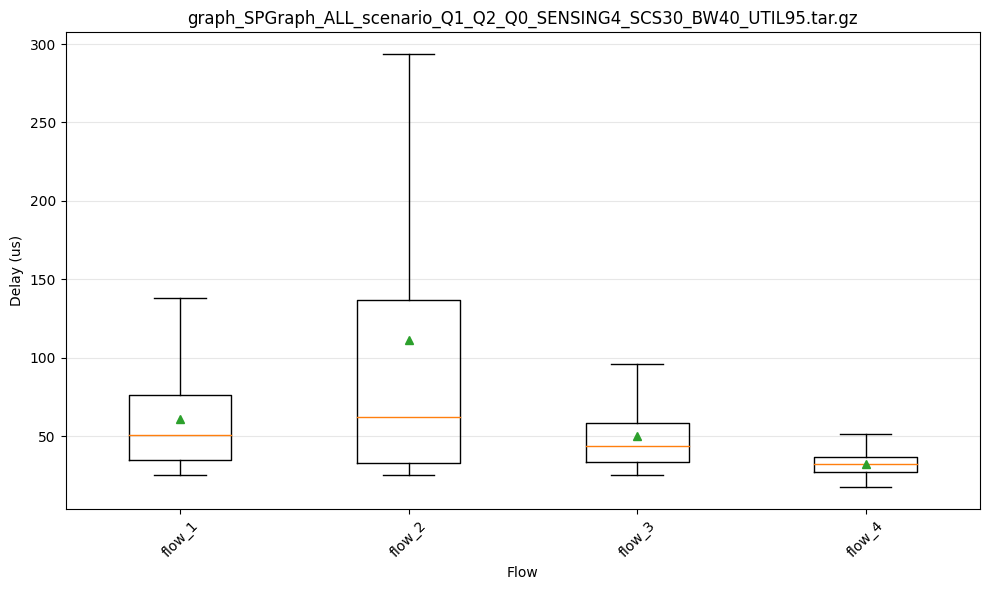

In [ ]:
from pathlib import Path
import tarfile
import re
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
dataset_root = Path("./generate-datasetsHQoS_multiproc/datasets/testing/train/").resolve()

TIME_SCALE = 1e3
UTIL_THRESHOLD_UPPER = 95  # filtro
UTIL_THRESHOLD_LOWER = 90  # filtro

# =========================
# BUSCAR TARFILES
# =========================
tar_files = list(dataset_root.rglob("*.tar")) + list(dataset_root.rglob("*SPGraph*scenario_Q1_Q0_Q2*.tar.gz"))

if not tar_files:
    print("No se encontraron tarfiles")
    exit()

print(f"Encontrados {len(tar_files)} tarfiles")

# =========================
# FILTRAR TARFILES POR NOMBRE
# =========================
selected_tars = []

for tar_path in tar_files:
    match = re.search(r"_UTIL(\d+(?:\.\d+)?)", tar_path.name)
    if match:
        util_value = float(match.group(1))
        if UTIL_THRESHOLD_LOWER < util_value < UTIL_THRESHOLD_UPPER:
            selected_tars.append(tar_path)

if not selected_tars:
    print("No hay tarfiles que cumplan el filtro, usando todos")
    selected_tars = tar_files


# =========================
# EXTRAER DELAYS DESDE TAR
# =========================
def extract_flow_delays_from_tar(tar, flow_id):
    tx_name_pattern = re.compile(rf".*/txfileflow{flow_id}\.txt$")
    rx_name_pattern = re.compile(rf".*/rxfileflow{flow_id}\.txt$")

    tx_member = None
    rx_member = None

    for m in tar.getmembers():
        if tx_name_pattern.match(m.name):
            tx_member = m
        elif rx_name_pattern.match(m.name):
            rx_member = m

    if tx_member is None or rx_member is None:
        return None

    tx_file = tar.extractfile(tx_member)
    rx_file = tar.extractfile(rx_member)

    tx_times = {}

    # TX
    for line in tx_file:
        parts = line.decode().strip().split()
        if len(parts) >= 2:
            tx_times[int(parts[0])] = float(parts[1])

    # RX
    delays = []
    for line in rx_file:
        parts = line.decode().strip().split()
        if len(parts) >= 2:
            pkt_id = int(parts[0])
            rx_t = float(parts[1])

            if pkt_id in tx_times:
                d = (rx_t - tx_times[pkt_id]) / TIME_SCALE
                if d >= 0:
                    delays.append(d)

    return np.array(delays) if delays else None


# =========================
# PROCESAR UN TAR
# =========================
def process_tar(tar_path):
    print(f"\nProcesando {tar_path.name}")

    with tarfile.open(tar_path, "r:*") as tar:

        # detectar flows
        flow_ids = set()

        for m in tar.getmembers():
            match = re.search(r"rxfileflow(\d+)\.txt$", m.name)
            if match:
                flow_ids.add(int(match.group(1)))

        flow_ids = sorted(flow_ids)

        labels = []
        data = []

        for fid in flow_ids:
            delays = extract_flow_delays_from_tar(tar, fid)

            if delays is not None:
                mean_delay = np.mean(delays)
                print(f"{tar_path.name} | flow_{fid} -> mean: {mean_delay:.3f} us")

                labels.append(f"flow_{fid}")
                data.append(delays)

        if not data:
            print("Sin datos válidos")
            return

        total_mean = np.mean(np.concatenate(data))
        print(f">>> TOTAL mean delay: {total_mean:.3f} us")

        # plot
        fig_w = max(10, 1.2 * len(data))
        plt.figure(figsize=(fig_w, 6))
        plt.boxplot(data, labels=labels, showfliers=False, showmeans=True)
        plt.title(f"{tar_path.name}")
        plt.xlabel("Flow")
        plt.ylabel("Delay (us)")
        plt.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


# =========================
# MAIN
# =========================
for tar_path in selected_tars:
    process_tar(tar_path)

graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.560 us
graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 113.177 us
graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.841 us


graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 41.482 us

>>> graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 53.584 us



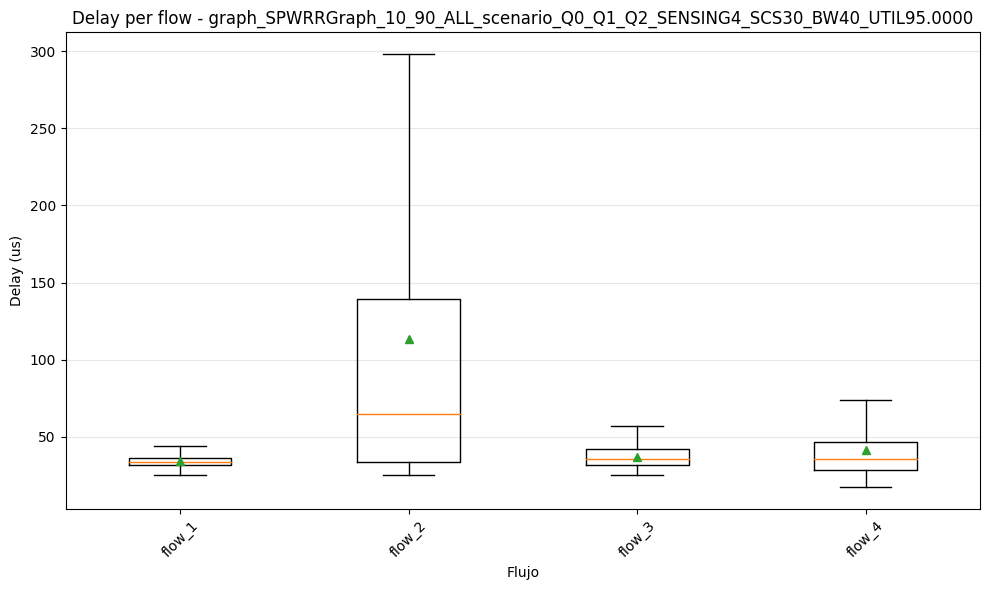

graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.768 us
graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 98.703 us
graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.687 us
graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 50.386 us

>>> graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 56.709 us



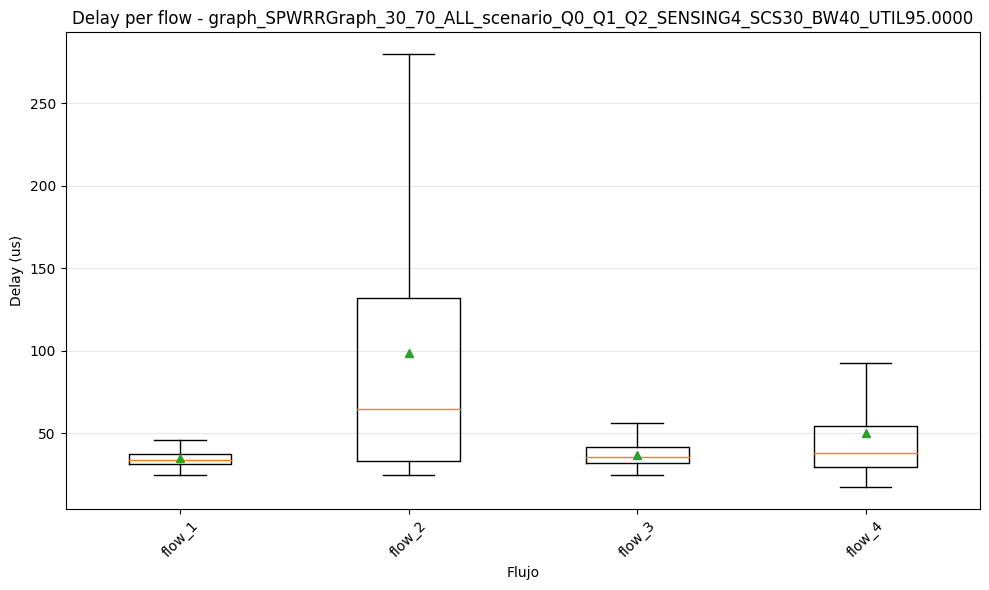

graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.309 us
graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 50.301 us
graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.254 us
graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 80.341 us

>>> graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 67.223 us



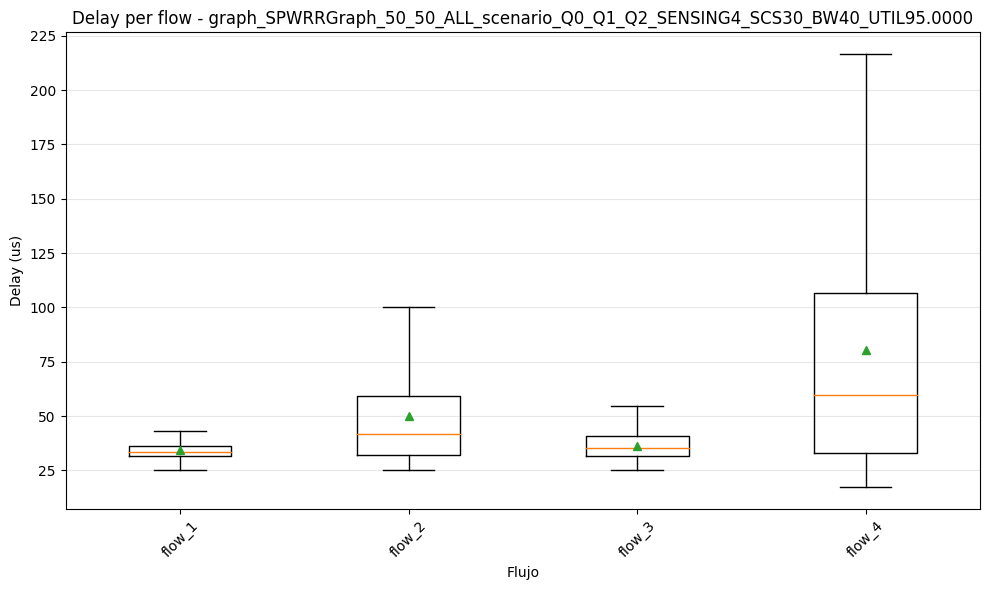

graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.199 us
graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 33.938 us
graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.003 us
graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 90.501 us

>>> graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 70.789 us



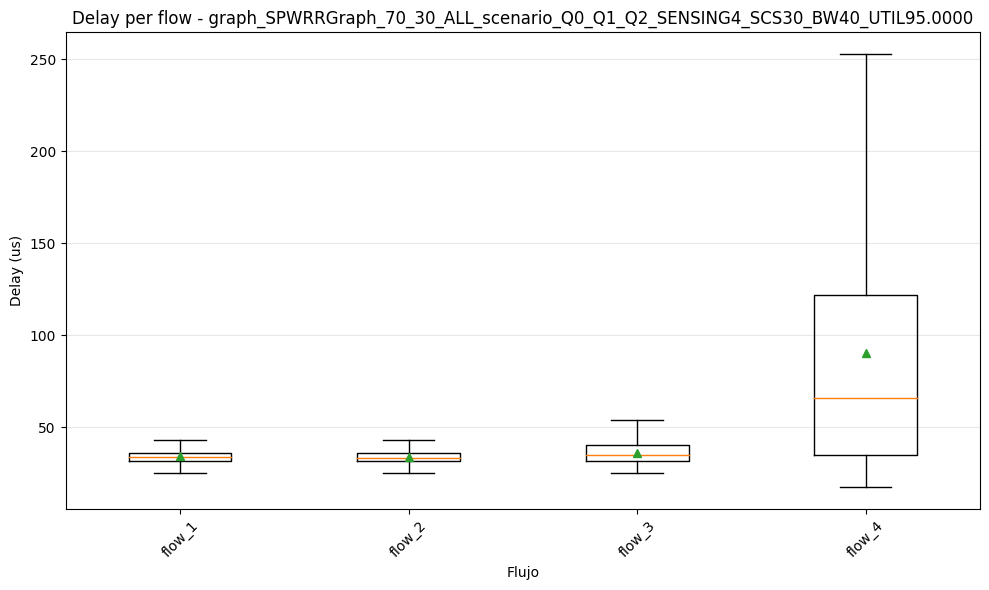

graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.199 us
graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 33.938 us
graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.003 us
graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 90.501 us

>>> graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 70.789 us



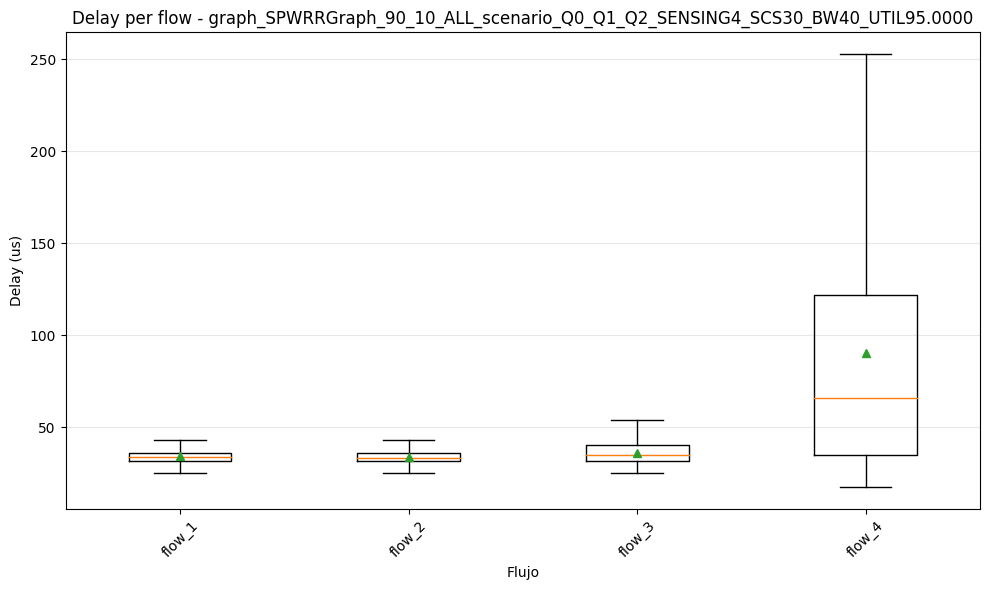

In [23]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

# Ruta al dataset (ajústala si cambiaste la estructura)
dataset_root = Path("./generate-datasetsHQoS/datasets/oran-hqos_test_2s/train/").resolve()

# Conversión de tiempo
TIME_SCALE = 1e3  # ns -> us

UTIL_THRESHOLD = 90  # Umbral

# 1. Obtener escenarios con UTIL > threshold
all_scenarios = sorted([p for p in dataset_root.iterdir() if p.is_dir() and p.name.startswith("graph_")])
scenario_dirs = []

for scen in all_scenarios:
    match = re.search(r"_UTIL(\d+(?:\.\d+)?)$", scen.name)
    if match:
        util_value = float(match.group(1))
        if util_value > UTIL_THRESHOLD:
            scenario_dirs.append(scen)

# =========================================================
# FUNCIÓN reutilizable para procesar un directorio
# =========================================================
def process_directory(base_dir):
    rx_files = sorted(base_dir.glob("rxfileflow*.txt"))
    flow_ids = []

    for f in rx_files:
        m = re.search(r"rxfileflow(\d+)\.txt$", f.name)
        if m:
            flow_ids.append(int(m.group(1)))

    flow_ids = sorted(set(flow_ids))

    labels = []
    data = []
    means = {}

    for fid in flow_ids:
        tx_path = base_dir / f"txfileflow{fid}.txt"
        rx_path = base_dir / f"rxfileflow{fid}.txt"

        if not tx_path.exists() or not rx_path.exists():
            continue

        # Leer TX
        tx_times = {}
        with tx_path.open("r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    pkt_id = int(parts[0])
                    tx_times[pkt_id] = float(parts[1])

        # Leer RX y calcular delays
        delays = []
        with rx_path.open("r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    pkt_id = int(parts[0])
                    rx_t = float(parts[1])

                    if pkt_id in tx_times:
                        d = (rx_t - tx_times[pkt_id]) / TIME_SCALE
                        if d >= 0:
                            delays.append(d)

        if len(delays) > 0:
            delays_array = np.array(delays, dtype=float)
            mean_delay = np.mean(delays_array)

            print(f"{base_dir.name} | flow_{fid} -> mean delay: {mean_delay:.3f} us")

            means[f"flow_{fid}"] = mean_delay
            labels.append(f"flow_{fid}")
            data.append(delays_array)

    if len(data) == 0:
        print(f"{base_dir.name}: sin delays válidos para pintar")
        return

    # Media total del escenario
    all_delays = np.concatenate(data)
    total_mean = np.mean(all_delays)

    print(f"\n>>> {base_dir.name} -> mean TOTAL delay: {total_mean:.3f} us\n")

    # Boxplot
    fig_w = max(10, 1.2 * len(data))
    plt.figure(figsize=(fig_w, 6))
    plt.boxplot(data, labels=labels, showfliers=False, showmeans=True)
    plt.title(f"Delay per flow - {base_dir.name}")
    plt.xlabel("Flujo")
    plt.ylabel("Delay (us)")
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================

if not scenario_dirs:
    print("No se encontraron escenarios filtrados. Procesando dataset_root directamente...\n")
    process_directory(dataset_root)
else:
    for scen_dir in scenario_dirs:
        process_directory(scen_dir)